In [ ]:
import pandas as pd
import numpy as np
import math

#  Load data
df = pd.read_csv('reviews.csv', dtype={'author_steamid': str, 'appid': str})
df['rating'] = df['voted_up'].astype(int) # Convert True/False to 1/0


user_to_game = df.groupby('author_steamid')['appid'].apply(list).to_dict()
game_to_user = df.groupby('appid')['author_steamid'].apply(list).to_dict()


user_game_to_rating = {}
for index, row in df.iterrows():
    user_game_to_rating[(row['author_steamid'], row['appid'])] = row['rating']


global_means = {}
for user, games in user_to_game.items():
    ratings = []
    for game in games:
        ratings.append(user_game_to_rating[(user, game)])
    global_means[user] = np.mean(ratings)


target_user = '76561198237676960'
target_games = set(user_to_game[target_user])
mu_target = global_means[target_user]


similarity_scores = {}
for other_user in user_to_game:
    if other_user == target_user:
        continue

    other_games = set(user_to_game[other_user])
    common_games = target_games.intersection(other_games)


    if len(common_games) >= 3:
        mu_other = global_means[other_user]
        numerator = 0
        den_target = 0
        den_other = 0

        for game in common_games:
            r_t = user_game_to_rating[(target_user, game)]
            r_o = user_game_to_rating[(other_user, game)]

            numerator += (r_t - mu_target) * (r_o - mu_other)
            den_target += (r_t - mu_target)**2
            den_other += (r_o - mu_other)**2


        if den_target > 0 and den_other > 0:
            sim = numerator / (math.sqrt(den_target) * math.sqrt(den_other))
        else:
            sim = 0
        similarity_scores[other_user] = sim


predicted_ratings = {}
for game in game_to_user:
    if game in target_games:
        continue

    raters = game_to_user[game]
    num = 0
    den = 0

    for u in raters:
        if u in similarity_scores:
            sim = similarity_scores[u]
            if sim != 0:
                num += sim * user_game_to_rating[(u, game)]
                den += abs(sim)

    if den > 0:
        predicted_ratings[game] = num / den


recommendations = sorted(predicted_ratings.items(), key=lambda x: x[1], reverse=True)[:5]

print(f"Recommendations for {target_user}:")
for game_id, score in recommendations:
    print(f"Game AppID: {game_id} | Predicted Score: {score:.2f}")

Recommendations for 76561198237676960:
Game AppID: 1000510 | Predicted Score: 1.00
Game AppID: 1000830 | Predicted Score: 1.00
Game AppID: 1001010 | Predicted Score: 1.00
Game AppID: 1001100 | Predicted Score: 1.00
Game AppID: 1001430 | Predicted Score: 1.00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('reviews.csv')


unique_users = df['author_steamid'].nunique()
unique_items = df['appid'].nunique()
total_rows = len(df)


possible_interactions = unique_users * unique_items
sparsity = 1 - (total_rows / possible_interactions)
sparsity_percentage = sparsity * 100

print("--- DATASET SUMMARY ---")
print("Total number of reviews:", total_rows)
print("Number of unique users:", unique_users)
print("Number of unique games:", unique_items)
print("Matrix Sparsity (%):", sparsity_percentage)
print("-----------------------")



--- DATASET SUMMARY ---
Total number of reviews: 1048148
Number of unique users: 701884
Number of unique games: 117311
Matrix Sparsity (%): 99.9987270289393
-----------------------


In [ ]:

user_counts = df.groupby('author_steamid')['appid'].count()
item_counts = df.groupby('appid')['author_steamid'].count()

users_with_one_review = sum(user_counts == 1)
print("Users with only 1 review:", users_with_one_review)



Users with only 1 review: 590409


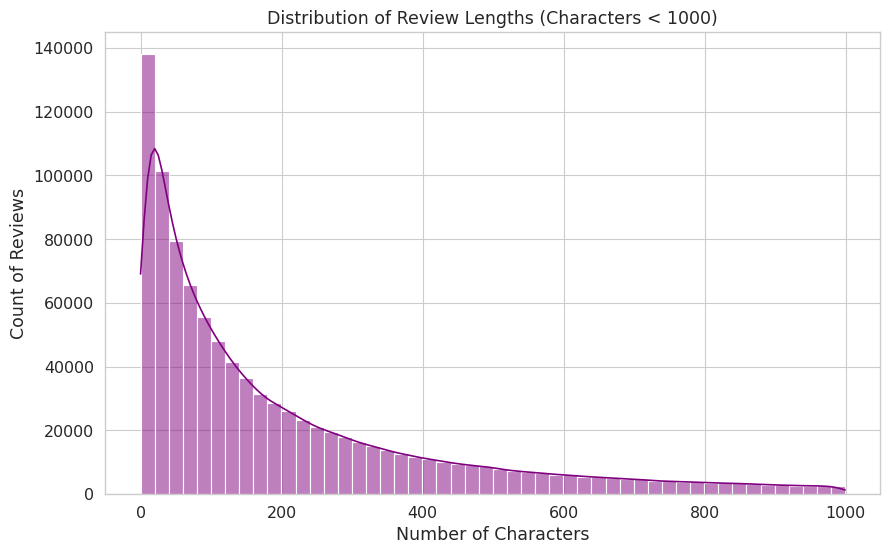

In [ ]:
df['review_char_count'] = df['review_text'].fillna('').apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df[df['review_char_count'] < 1000]['review_char_count'], bins=50, color='purple', kde=True)
plt.title('Distribution of Review Lengths (Characters < 1000)')
plt.xlabel('Number of Characters')
plt.ylabel('Count of Reviews')
plt.show()

/tmp/ipykernel_1485/2347591740.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='voted_up', y='author_num_games_owned', data=df, palette='muted')


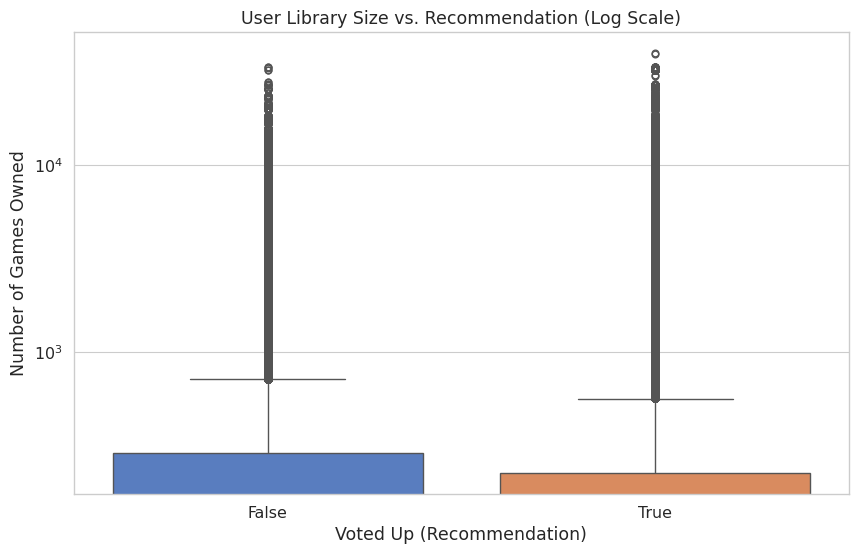

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='voted_up', y='author_num_games_owned', data=df, palette='muted')
plt.yscale('log')
plt.title('User Library Size vs. Recommendation (Log Scale)')
plt.xlabel('Voted Up (Recommendation)')
plt.ylabel('Number of Games Owned')
plt.show()

Text(0, 0.5, 'Count')

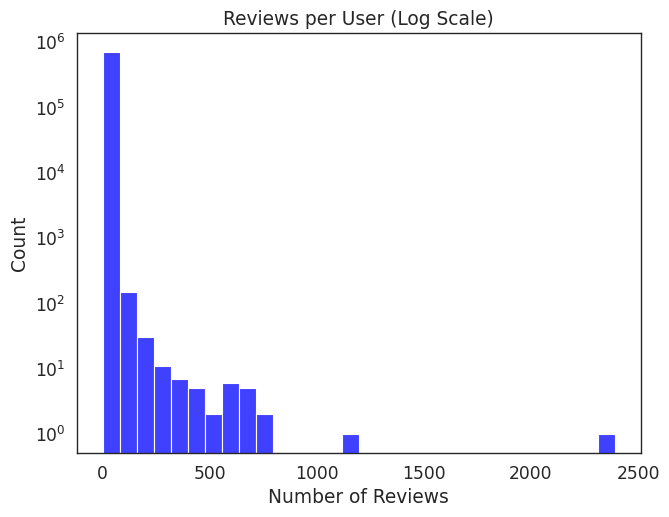

In [ ]:
sns.set_style("white")
sns.set_context("paper", font_scale=1.4)


plt.figure(figsize=(16, 12))


plt.subplot(2, 2, 1)
sns.histplot(user_counts, bins=30, color='blue')
plt.yscale('log')
plt.title('Reviews per User (Log Scale)')
plt.xlabel('Number of Reviews')
plt.ylabel('Count')

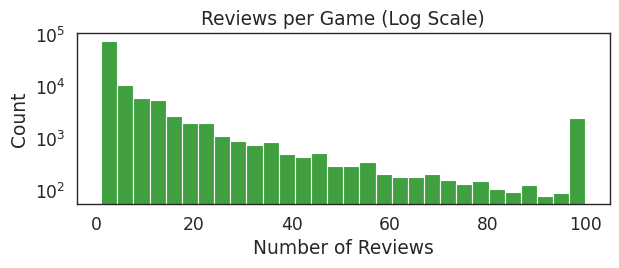

In [ ]:
plt.subplot(2, 1, 2)
sns.histplot(item_counts, bins=30, color='green')
plt.yscale('log')
plt.title('Reviews per Game (Log Scale)')
plt.xlabel('Number of Reviews')
plt.ylabel('Count')


plt.tight_layout()


plt.savefig("distribution_plots.png", dpi=300, bbox_inches='tight')

plt.show()

/tmp/ipykernel_1485/294196887.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='voted_up', data=df, palette=['#e74c3c', '#2ecc71'])


Text(0, 0.5, 'Count')

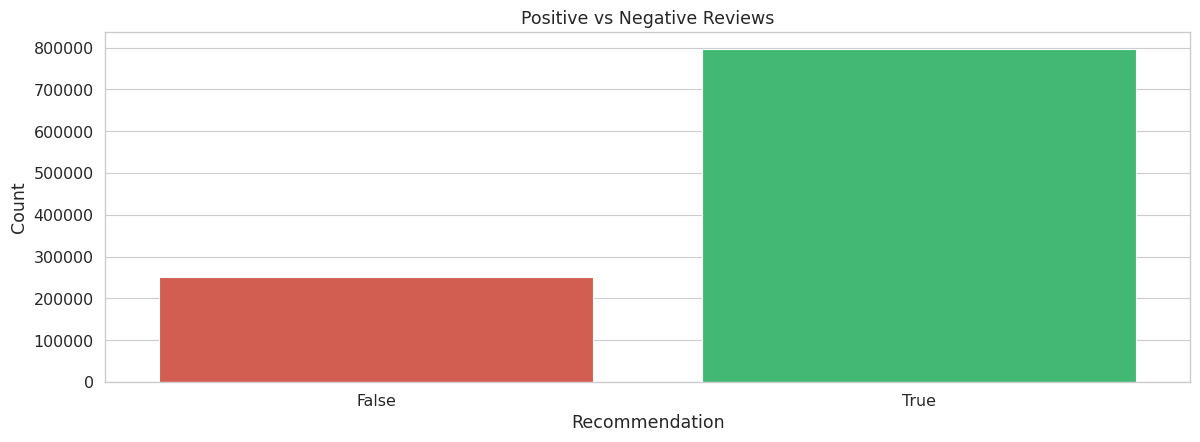

In [ ]:

sns.set_style("whitegrid")
plt.figure(figsize=(14, 10))


plt.subplot(2, 1, 1)
sns.countplot(x='voted_up', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Positive vs Negative Reviews')
plt.xlabel('Recommendation')
plt.ylabel('Count')

/tmp/ipykernel_1485/1227914842.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='voted_up', y='author_playtime_forever', data=df,


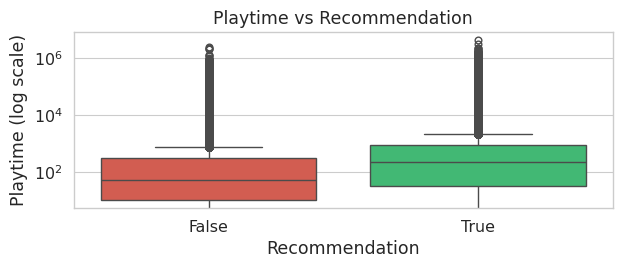

In [ ]:

plt.subplot(2, 1, 2)
sns.boxplot(x='voted_up', y='author_playtime_forever', data=df,
            palette=['#e74c3c', '#2ecc71'])
plt.yscale('log')
plt.title('Playtime vs Recommendation')
plt.xlabel('Recommendation')
plt.ylabel('Playtime (log scale)')

plt.tight_layout()
plt.savefig("plots.png", dpi=300, bbox_inches='tight')
plt.show()

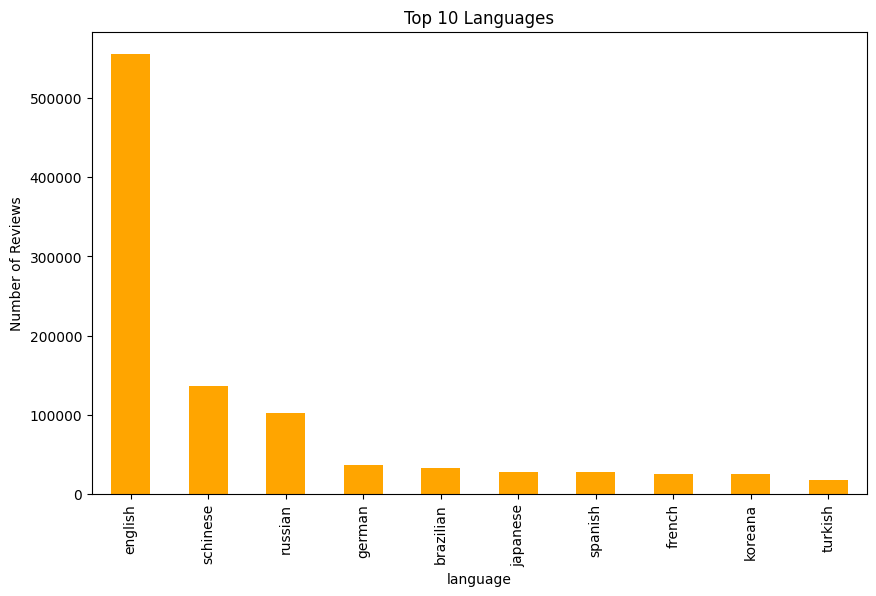

In [ ]:

plt.figure(figsize=(10, 6))
top_languages = df['language'].value_counts().head(10)
top_languages.plot(kind='bar', color='orange')
plt.title('Top 10 Languages')
plt.ylabel('Number of Reviews')
plt.show()



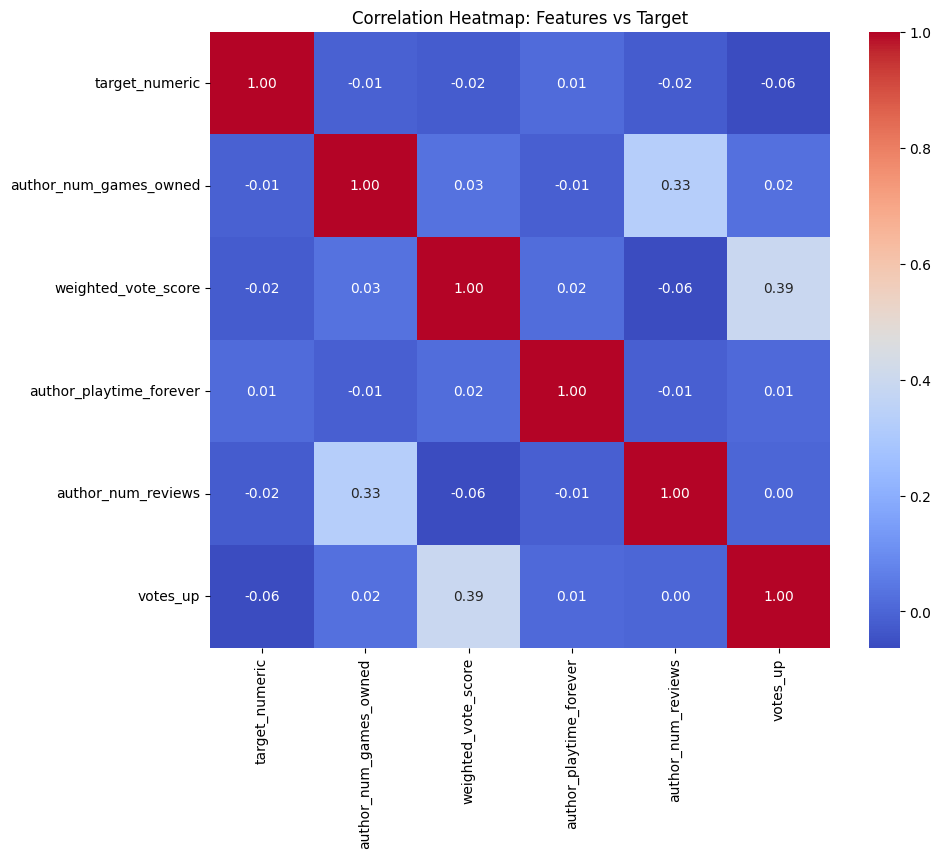

In [ ]:

df['target_numeric'] = df['voted_up'].astype(int)
eda_features = ['target_numeric', 'author_num_games_owned', 'weighted_vote_score',
                'author_playtime_forever', 'author_num_reviews', 'votes_up']

plt.figure(figsize=(10, 8))
sns.heatmap(df[eda_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Features vs Target')
plt.show()

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split


df = pd.read_csv('reviews.csv')
apps_df = pd.read_csv('applications.csv')


df = pd.merge(df, apps_df[['appid', 'name']], on='appid', how='left')


df['log_playtime'] = np.log1p(df['author_playtime_forever'])

df['proxy_score'] = (
    df['voted_up'].astype(int) * 2 +
    df['weighted_vote_score'] +
    df['log_playtime'] * 0.15
)

features = ['author_num_games_owned', 'log_playtime', 'weighted_vote_score']
target = 'voted_up'
df_ml = df.dropna(subset=features + [target]).copy()

X = df_ml[features]
y = df_ml[target].astype(int)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(scaler.fit_transform(X_train))
X_test_poly = poly.transform(scaler.transform(X_test))


model = LogisticRegression(penalty=None, max_iter=30000)
model.fit(X_train_poly, y_train)



game_stats = df.groupby('appid').agg(
    name=('name', 'first'),
    proxy_score=('proxy_score', 'mean'),
    review_count=('author_steamid', 'count'),
    weighted_vote_score=('weighted_vote_score', 'mean')
)

C = game_stats['review_count'].mean()
m = game_stats['proxy_score'].mean()
game_stats['bayesian_quality'] = (
    (game_stats['review_count'] / (game_stats['review_count'] + C) * game_stats['proxy_score']) +
    (C / (game_stats['review_count'] + C) * m)
)


def get_recommendations(user_id, k=5):
    user_data = df[df['author_steamid'] == user_id]

    if user_data.empty:
        user_owned = df['author_num_games_owned'].mean()
        user_playtime = df['log_playtime'].mean()
        user_history = []
    else:
        user_owned = user_data['author_num_games_owned'].iloc[0]
        user_playtime = user_data['log_playtime'].mean()
        user_history = user_data['appid'].unique().tolist()

    pred_df = game_stats.copy()
    pred_df['author_num_games_owned'] = user_owned
    pred_df['log_playtime'] = user_playtime

    X_input = poly.transform(scaler.transform(pred_df[features]))
    ml_probs = model.predict_proba(X_input)[:, 1]

    pred_df['hybrid_score'] = (pred_df['bayesian_quality'] * 0.6) + (ml_probs * 0.4)


    recommendations = pred_df[~pred_df.index.isin(user_history)].sort_values('hybrid_score', ascending=False)


    return recommendations[['name', 'hybrid_score']].head(k)

print(f"Training Log Loss (with Playtime): {log_loss(y_train, model.predict_proba(X_train_poly)):.4f}")



/tmp/ipykernel_11283/2453263782.py:10: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  apps_df = pd.read_csv('applications.csv')


Training Log Loss (with Playtime): 0.5294


In [4]:
from sklearn.metrics import log_loss, precision_score, recall_score, f1_score, classification_report


y_prob = model.predict_proba(X_test_poly)[:, 1]

#  0.5 threshold
y_pred = (y_prob >= 0.5).astype(int)

#  Metrics
logloss_val = log_loss(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"--- Evaluation Results ---")
print(f"Log Loss:  {logloss_val:.4f}")
print(f"Precision: {precision:.4f} (How many recommended 'Upvotes' were actually correct)")
print(f"Recall:    {recall:.4f} (How many actual 'Upvotes' did the model successfully find)")
print(f"F1-Score:  {f1:.4f} (The balance between Precision and Recall)")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))


sample_user = df['author_steamid'].dropna().iloc[0]
print(f"\nTop Recommendations for User {sample_user}:")
print(get_recommendations(sample_user))

--- Evaluation Results ---
Log Loss:  0.5323
Precision: 0.7609 (How many recommended 'Upvotes' were actually correct)
Recall:    0.9943 (How many actual 'Upvotes' did the model successfully find)
F1-Score:  0.8621 (The balance between Precision and Recall)

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.02      0.04     50634
           1       0.76      0.99      0.86    158995

    accuracy                           0.76    209629
   macro avg       0.64      0.51      0.45    209629
weighted avg       0.70      0.76      0.66    209629


Top Recommendations for User 76561198085405844:
                  name  hybrid_score
appid                               
238960   Path of Exile      2.610293
294100        RimWorld      2.583520
427520        Factorio      2.564890
413150  Stardew Valley      2.562061
526870    Satisfactory      2.559822


In [5]:


user_id_1 = df['author_steamid'].dropna().iloc[0]
user_id_2 = df['author_steamid'].dropna().iloc[500]

print(f"--- Comparison of Recommendations ---")

print(f"\nTop Recommendations for User A ({user_id_1}):")
recommendations_a = get_recommendations(user_id_1)
print(recommendations_a)

print(f"\nTop Recommendations for User B ({user_id_2}):")
recommendations_b = get_recommendations(user_id_2)
print(recommendations_b)



--- Comparison of Recommendations ---

Top Recommendations for User A (76561198085405844):
                  name  hybrid_score
appid                               
238960   Path of Exile      2.610293
294100        RimWorld      2.583520
427520        Factorio      2.564890
413150  Stardew Valley      2.562061
526870    Satisfactory      2.559822

Top Recommendations for User B (76561198870355816):
                  name  hybrid_score
appid                               
238960   Path of Exile      2.609194
294100        RimWorld      2.582184
413150  Stardew Valley      2.562372
427520        Factorio      2.561947
526870    Satisfactory      2.557993


Hybrid Model RMSE: 0.4179


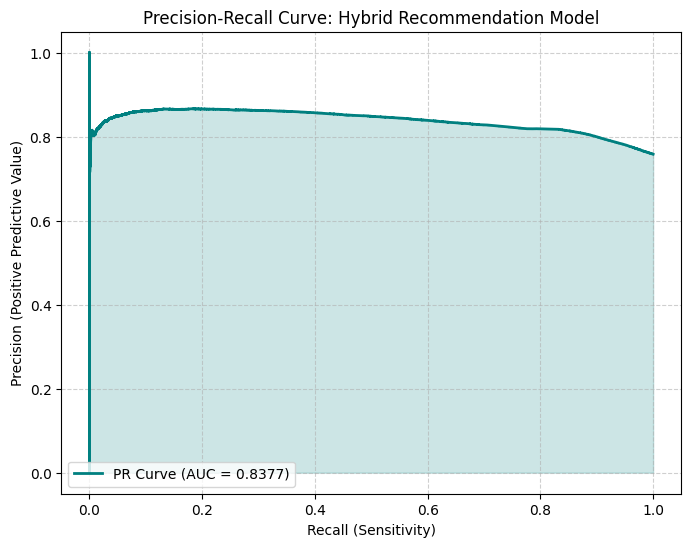

Precision-Recall AUC: 0.8377


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

from sklearn.metrics import mean_squared_error
import numpy as np


hybrid_mse = mean_squared_error(y_test, model.predict_proba(X_test_poly)[:, 1])
hybrid_rmse = np.sqrt(hybrid_mse)
print(f"Hybrid Model RMSE: {hybrid_rmse:.4f}")


precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)


pr_auc = auc(recall_vals, precision_vals)

# 3. Plotting
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='teal', lw=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.2, color='teal')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve: Hybrid Recommendation Model')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Precision-Recall AUC: {pr_auc:.4f}")